# Detecção de Objetos com YOLOS

Neste notebook, utilizaremos o modelo `hustvl/yolos-small` do Hugging Face para realizar a detecção de objetos nas imagens contidas na pasta `testes`.

In [1]:
import os
import torch
from PIL import Image
from transformers import YolosImageProcessor, YolosForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Definir o caminho para a pasta de imagens
PASTA_IMAGENS = "C:/Users/luiz/Pictures/testes/"

# 2. Carregar o modelo e o processador de imagens do YOLOS
processor = YolosImageProcessor.from_pretrained("hustvl/yolos-small")
model = YolosForObjectDetection.from_pretrained("hustvl/yolos-small")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

### Iterando as imagens de `PASTA_IMAGENS` e Detectando Objetos


🔎 Vasculhando imagens na pasta: C:/Users/luiz/Pictures/testes/
...

--- Detecções em 2c534b3c154e6035078c2afcfe448509_thumb.jpeg ---


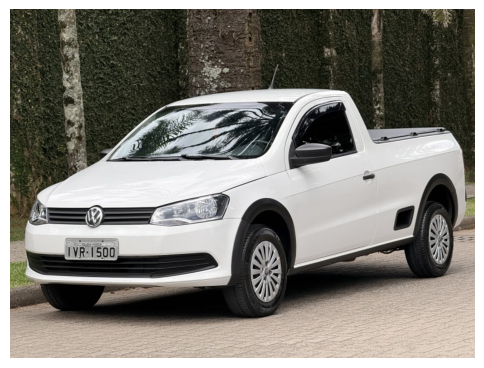


--- Detecções em Imagem do WhatsApp de 2025-11-04 à(s) 17.41.18_75eb3b4c.jpg ---
Detectado book com confiança 0.94 em [3.42, 1307.69, 544.4, 1591.08]
Detectado person com confiança 0.999 em [1.41, 273.26, 1134.23, 1582.35]
Detectado book com confiança 0.914 em [0.45, 1187.7, 157.3, 1498.57]


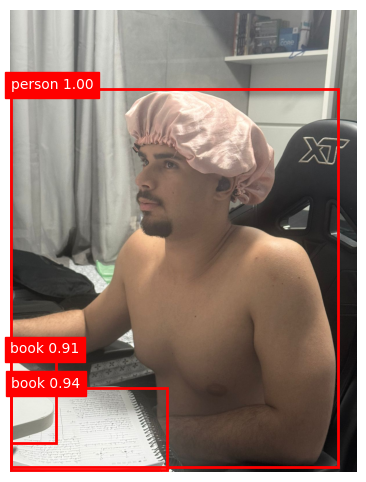


--- Detecções em racas-de-cachorro-golden-retriever-cpt11.jpg ---
Detectado dog com confiança 1.0 em [189.85, 0.08, 542.6, 478.4]


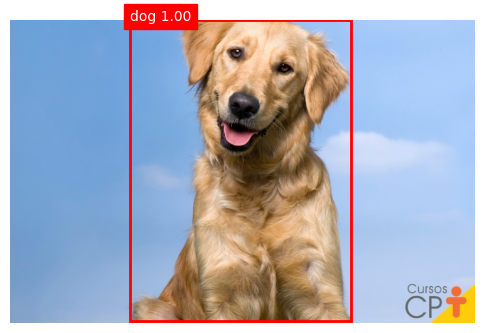


--- Detecções em vida-de-gato.jpg ---
Detectado cat com confiança 1.0 em [118.29, 10.83, 602.04, 430.94]


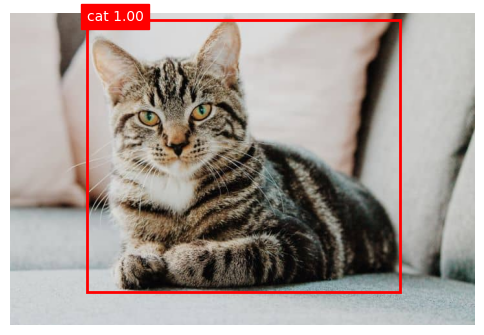

In [2]:
print(f"\n🔎 Vasculhando imagens na pasta: {PASTA_IMAGENS}\n...")

if not os.path.exists(PASTA_IMAGENS):
    print("Pasta de imagens não encontrada! Verifique o caminho.")
else:
    for filename in os.listdir(PASTA_IMAGENS):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(PASTA_IMAGENS, filename)
            image = Image.open(img_path).convert("RGB")
            
            inputs = processor(images=image, return_tensors="pt")
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            target_sizes = torch.tensor([image.size[::-1]])
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]
            
            fig, ax = plt.subplots(1, figsize=(6, 6))
            ax.imshow(image)
            ax.axis("off")
            
            print(f"\n--- Detecções em {filename} ---")
            for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
                box = [round(i, 2) for i in box.tolist()]
                label_name = model.config.id2label[label.item()]
                print(f"Detectado {label_name} com confiança {round(score.item(), 3)} em {box}")
                
                xmin, ymin, xmax, ymax = box
                rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                plt.text(xmin, ymin, f"{label_name} {score.item():.2f}", color='white', backgroundcolor='red')
                
            plt.show()